# BbValidator: как это работает

Живой проход пайплайна: PDB → биофизический фронтенд → графовый энкодер → многозадачные головы → MC-Dropout вердикт.

Нужны обученный чекпоинт `checkpoints/best_model.pth` и образцы в `data/`. Соответствует модулям [02](../docs/02-biofizicheskiy-frontend.md) и [03](../docs/03-model-i-obuchenie.md) документации.

In [1]:
# Jupyter открывает тетрадь в notebooks/, а пути проекта относительны от корня.
# Поднимаемся до корня репозитория при необходимости.
import os
while not os.path.exists("inference.py") and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir("..")
assert os.path.exists("inference.py"), "Откройте тетрадь внутри репозитория BbValidator"
print("Корень репозитория:", os.getcwd())

Корень репозитория: /home/pc/PycharmProjects/BbValidator


In [2]:
import glob
import torch

from inference import _autocast_ctx, build_model, center_coords, parse_pdb_to_backbone
from model.heads_loss import predict_with_uncertainty
from filter_designability import FAILURE_MODE_NAMES

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
model = build_model("checkpoints/best_model.pth", device)

/home/pc/PycharmProjects/BbValidator/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Устройство: cuda
Загрузка весов из checkpoints/best_model.pth...


## 1. Парсинг backbone

Из PDB берутся только атомы остова: `[N, Cα, C]` на остаток → тензор `[B, N, 3, 3]`, координаты центрируются. Стереохимия восстанавливается из геометрии остова — ни последовательность, ни сайдчейны не нужны.

In [3]:
coords_np = center_coords(parse_pdb_to_backbone("data/2RJV.pdb"))
coords = torch.from_numpy(coords_np).unsqueeze(0).to(device)
mask = torch.ones((1, coords.shape[1]), dtype=torch.bool, device=device)

print(f"Длина: {coords.shape[1]} остатков | тензор: {tuple(coords.shape)} = (B, N, 3 атома, 3 координаты)")
coords[0, :2]  # первые два остатка: N, Cα, C

Длина: 67 остатков | тензор: (1, 67, 3, 3) = (B, N, 3 атома, 3 координаты)


tensor([[[ 7.1931, 17.3472, -2.0727],
         [ 5.8340, 17.2802, -2.6657],
         [ 4.7270, 17.2362, -1.6137]],

        [[ 3.5030, 17.5342, -2.0397],
         [ 2.3420, 17.5222, -1.1497],
         [ 2.2541, 16.1582, -0.4687]]], device='cuda:0')

## 2. Биофизический фронтенд

Детерминированная «физика» (считается один раз):
- **геометрия** — торсионы φ/ψ/ω, CA-дистанции, счётчики H-связей и стерических конфликтов;
- **прокси дизайнуемости** — плотность упаковки, экспонированность растворителю, PCA-проекции фрагментов;
- **граф** — kNN по Cα (k=16) с RBF-кодированием дистанций.

На выходе узловые признаки `[B, N, 31]` = геометрия (10) + прокси (21).

In [4]:
with torch.no_grad():
    geom = model.frontend.geometry(coords, mask)
    front = model.frontend(coords, mask)

print("Сырые геометрические диагностики (всего по структуре):")
print(f"  стерические конфликты (Cβ < 3.5 Å, |i-j| ≥ 3): {int(geom['clash_count'].sum() / 2)}")
print(f"  H-связи остова: {int(geom['hbond_count'].sum())}")
print()
print("Узловые признаки:", tuple(front["node_feats"].shape))
print("Рёбра графа:", front["edge_indices"][0].shape[1], "(k=16 соседей × N остатков)")
front["node_feats"][0, :3, :8].float().round(decimals=3)

Сырые геометрические диагностики (всего по структуре):
  стерические конфликты (Cβ < 3.5 Å, |i-j| ≥ 3): 1
  H-связи остова: 51

Узловые признаки: (1, 67, 31)
Рёбра графа: 1072 (k=16 соседей × N остатков)


tensor([[ 0.0000,  0.0000,  0.2990, -0.9540,  0.0000,  0.0000,  0.4070,  0.0000],
        [-0.8150,  0.5790,  0.6650, -0.7470,  0.0100, -1.0000,  0.4010,  0.0000],
        [-0.8650,  0.5010,  0.6990, -0.7150,  0.0110, -1.0000,  0.4040,  0.0000]],
       device='cuda:0')

## 3. Энкодер + головы + MC-Dropout

Фронтенд прогоняется один раз, затем `mc_runs` проходов энкодера с включённым дропаутом: разброс предсказаний — эпистемическая неопределённость. Головы: P(fold), предсказанный RMSD, стерика, failure mode.

In [5]:
with torch.no_grad(), _autocast_ctx(device):
    mc = predict_with_uncertainty(model, coords, mask, mc_runs=16)
    preds = model(coords, mask)

pfold = mc["p_foldable"].item()
unc = mc["uncertainty"].item()
rmsd = max(0.0, torch.expm1(preds["rmsd"]).item())
p_steric = torch.sigmoid(preds["steric"]).item()
fm = torch.softmax(preds["failure_mode"].float(), dim=-1)[0]

print(f"P(fold)              = {pfold:.3f}  (MC-дисперсия {unc:.5f})")
print(f"Предсказанный RMSD   = {rmsd:.2f} Å")
print(f"Вероятность стерики  = {p_steric:.3f}")
print("Failure mode         =", {FAILURE_MODE_NAMES[i]: f"{v:.2f}" for i, v in enumerate(fm.tolist())})

P(fold)              = 1.000  (MC-дисперсия 0.00000)
Предсказанный RMSD   = 0.00 Å
Вероятность стерики  = 0.508
Failure mode         = {'ok': '1.00', 'easy': '0.00', 'hard': '0.00', 'near_native': '0.00', 'borderline': '0.00', 'unknown': '0.00'}


## 4. Все образцы в data/

Скоринг каждого файла по отдельности (B=1) и ранжирование по P(fold).

In [6]:
import pandas as pd

rows = []
for path in sorted(glob.glob("data/*.pdb")):
    c = torch.from_numpy(center_coords(parse_pdb_to_backbone(path))).unsqueeze(0).to(device)
    m = torch.ones((1, c.shape[1]), dtype=torch.bool, device=device)
    with torch.no_grad(), _autocast_ctx(device):
        r = predict_with_uncertainty(model, c, m, mc_runs=16)
        p = model(c, m)
        clashes = int((model.frontend.geometry(c, m)["clash_count"].sum() / 2).item())
    rows.append({
        "структура": path.split("/")[-1],
        "L": c.shape[1],
        "pfold": round(r["p_foldable"].item(), 3),
        "uncertainty": round(r["uncertainty"].item(), 5),
        "rmsd_pred": round(max(0.0, torch.expm1(p["rmsd"]).item()), 2),
        "конфликты": clashes,
    })

pd.DataFrame(rows).sort_values("pfold", ascending=False).reset_index(drop=True)

,структура,L,pfold,uncertainty,rmsd_pred,конфликты
0,2RJV.pdb,67,1.0,0.0,0.00,1
1,3MYC.pdb,64,1.0,0.0,0.00,0
2,my_protein_0.pdb,234,1.0,0.0,0.00,1
3,my_protein_1.pdb,204,1.0,0.0,0.00,1
4,my_protein_2.pdb,242,1.0,0.0,0.00,2
5,my_protein_4.pdb,216,1.0,0.0,0.00,0
6,my_protein_3.pdb,202,1.0,0.0,0.00,0
7,my_protein_5.pdb,216,1.0,0.0,0.00,0
8,2RJW.pdb,134,0.0,0.0,17.88,1


Этот же пайплайн в батчевом виде использует `filter_designability.py` — фильтр по дизайнуемости с настраиваемыми гейтами (P(fold), стерика, конфликты, RMSD, неопределённость) и подробным вердиктом, какие метрики завалены:

```bash
python filter_designability.py -i data/ood/evodiff/scaffolds --min-pfold 0.5 --max-clashes 2
```

## 5. Диагностика: какие признаки роняют P(fold)

Модель — глубокая нелинейная многозадачная сеть (MPNN + Transformer + attention-пулинг), поэтому `fold_logit` не раскладывается по входным признакам аналитически. Чтобы понять, **какие конкретно из 31 узловых признаков фронтенда тянут скор данного белка вниз**, используется **Integrated Gradients** (Sundararajan et al., 2017):

$$\text{attr}(f) = (x_f - x_f^{base}) \cdot \int_{\alpha=0}^{1} \frac{\partial\, \text{fold\_logit}(x^{base} + \alpha(x - x^{base}))}{\partial x_f}\, d\alpha$$

Интеграл аппроксимируется суммой по `steps` шагам вдоль прямой от `baseline` (типичный «хорошо сворачиваемый» белок — среднее по нескольким high-P(fold) структурам из `data/`, см. таблицу раздела 4) до фактических признаков белка `x`.

**Аксиома полноты**: сумма атрибуций по всем 31 признакам и всем остаткам точно равна `fold_logit(белок) − fold_logit(эталон)`. Поэтому вклад каждого признака измеряется в тех же единицах (логит), что и сам скор, и вклады можно складывать и сравнивать напрямую — это проверяется явно в примере ниже.

Ограничения метода:
- атрибуция **относительна к выбранному эталону** — это не абсолютная «вина» признака, а то, насколько его значение у данного белка хуже типичного фолдируемого;
- фронтенд заморожен (`no_grad` по конструкции, см. раздел 2), поэтому атрибуция считается от **узловых признаков** как входа — атрибуция самих координат или графа рёбер (kNN, RBF-дистанции) не выполняется;
- считается в **eval-режиме без MC-Dropout** (детерминированный проход) — ради стабильного объяснения; итоговый P(fold) поэтому немного отличается от MC-усреднённого из раздела 3, оба значения печатаются ниже для сравнения;
- 16 из 31 признаков — коррелированные PCA-компоненты фрагментов, вклад одной физической причины может «размазываться» между несколькими из них.

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Порядок ровно соответствует конкатенации в BiophysicalFrontend.forward:
# geometry.pack_for_mlp() (10) ++ designability.pack_for_mlp() (21) = 31
FEATURE_NAMES = [
    "φ sin", "φ cos", "ψ sin", "ψ cos", "ω sin", "ω cos",
    "Cα-Cα дист.", "Рамачандран-аутлайер", "H-связи", "стерич. конфликты",
    "упаковка r≤6Å", "упаковка r≤8Å", "упаковка r≤10Å",
    "экспонированность (burial)", "локальный изгиб",
] + [f"PCA-фрагмент {i}" for i in range(16)]
assert len(FEATURE_NAMES) == 31


def structure_node_feats(path: str) -> torch.Tensor:
    """Узловые признаки фронтенда [L, 31] для одного PDB (без паддинга)."""
    c = torch.from_numpy(center_coords(parse_pdb_to_backbone(path))).unsqueeze(0).to(device)
    m = torch.ones((1, c.shape[1]), dtype=torch.bool, device=device)
    with torch.no_grad():
        nf = model.frontend(c, m)["node_feats"][0]
    return nf


# "Эталон" — усреднённый по остаткам вектор признаков для нескольких
# структур с высоким P(fold) из таблицы раздела 4 (все получают P(fold) = 1.000 у переобученной модели).
GOOD_REFS = [
    "data/3MYC.pdb", "data/my_protein_1.pdb", "data/my_protein_3.pdb",
    "data/my_protein_4.pdb", "data/my_protein_5.pdb",
]
baseline_feats = torch.stack([structure_node_feats(p).mean(dim=0) for p in GOOD_REFS]).mean(dim=0)
assert baseline_feats.shape[-1] == len(FEATURE_NAMES)
print(f"Эталонный вектор признаков усреднён по {len(GOOD_REFS)} хорошо сворачиваемым структурам: {GOOD_REFS}")

Эталонный вектор признаков усреднён по 5 хорошо сворачиваемым структурам: ['data/3MYC.pdb', 'data/my_protein_1.pdb', 'data/my_protein_3.pdb', 'data/my_protein_4.pdb', 'data/my_protein_5.pdb']


In [8]:
def integrated_gradients(pdb_path: str, baseline: torch.Tensor, steps: int = 64) -> dict:
    """Integrated Gradients fold_logit по узловым признакам одного белка.

    Возвращает атрибуции [L, 31] в логит-юнитах + логиты белка/эталона —
    их разность должна совпасть с суммой атрибуций (аксиома полноты).
    """
    was_training = model.training
    model.eval()  # детерминированная атрибуция, без MC-Dropout
    try:
        coords_np = center_coords(parse_pdb_to_backbone(pdb_path))
        coords = torch.from_numpy(coords_np).unsqueeze(0).to(device)
        mask = torch.ones((1, coords.shape[1]), dtype=torch.bool, device=device)

        with torch.no_grad():
            features = model.frontend(coords, mask)  # фронтенд заморожен — дальше него атрибуция не идёт

        node_feats = features["node_feats"]  # [1, L, 31]
        base = baseline.view(1, 1, -1).expand_as(node_feats).to(node_feats.dtype)

        def logit_at(nf: torch.Tensor) -> torch.Tensor:
            feats_step = dict(features)
            feats_step["node_feats"] = nf
            protein_repr, _ = model.encode_features(feats_step)
            return model.predict_from_repr(protein_repr)["fold_logit"]

        grad_accum = torch.zeros_like(node_feats)
        for step in range(1, steps + 1):
            alpha = step / steps
            interp = (base + alpha * (node_feats - base)).clone().requires_grad_(True)
            logit = logit_at(interp)
            grad, = torch.autograd.grad(logit, interp)
            grad_accum += grad

        avg_grad = grad_accum / steps
        attributions = (avg_grad * (node_feats - base))[0]  # [L, 31]

        with torch.no_grad():
            logit_input = logit_at(node_feats).item()
            logit_baseline = logit_at(base).item()

        return {
            "path": pdb_path,
            "length": coords.shape[1],
            "attributions": attributions.detach().cpu(),
            "logit_input": logit_input,
            "logit_baseline": logit_baseline,
            "pfold_input": torch.sigmoid(torch.tensor(logit_input)).item(),
            "pfold_baseline": torch.sigmoid(torch.tensor(logit_baseline)).item(),
        }
    finally:
        model.train(was_training)

### Пример: `2RJW.pdb` — почему P(fold) ≈ 0

Единственная структура из таблицы раздела 4, которую переобученная модель отвергает (`pfold = 0.000`, предсказанный RMSD ~17.9 Å, 1 стерический конфликт); все остальные образцы `data/` получают P(fold) = 1.000 — после исключения шумных borderline-меток модель стала заметно «доверяющей» на около-нативных структурах. Проверяем аксиому полноты и печатаем топ-10 признаков, сильнее всего понижающих скор относительно эталона.

/home/pc/PycharmProjects/BbValidator/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


data/2RJW.pdb  (L=134)
  fold_logit(белок)  = -26.069  -> P(fold) = 0.000
  fold_logit(эталон) = +17.112  -> P(fold) = 1.000
  Sum атрибуций      = -42.278   (аксиома полноты: должна ~= -43.181)

Признаки, сильнее всего понижающие P(fold) относительно эталона:
  ω cos                         -7.226
  PCA-фрагмент 14               -6.751
  PCA-фрагмент 15               -5.313
  PCA-фрагмент 9                -4.760
  PCA-фрагмент 11               -2.966
  экспонированность (burial)    -2.680
  PCA-фрагмент 1                -2.052
  ψ sin                         -1.928
  PCA-фрагмент 12               -1.781
  PCA-фрагмент 8                -1.742


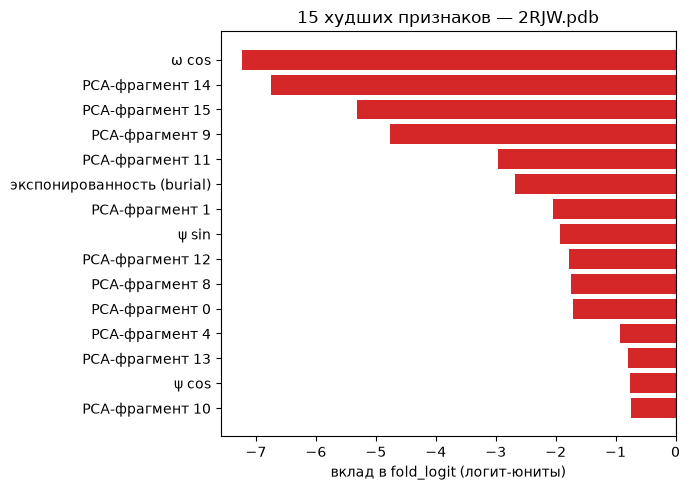

In [9]:
res = integrated_gradients("data/2RJW.pdb", baseline_feats)

sum_attr = res["attributions"].sum().item()
logit_diff = res["logit_input"] - res["logit_baseline"]

print(f"{res['path']}  (L={res['length']})")
print(f"  fold_logit(белок)  = {res['logit_input']:+.3f}  -> P(fold) = {res['pfold_input']:.3f}")
print(f"  fold_logit(эталон) = {res['logit_baseline']:+.3f}  -> P(fold) = {res['pfold_baseline']:.3f}")
print(f"  Sum атрибуций      = {sum_attr:+.3f}   (аксиома полноты: должна ~= {logit_diff:+.3f})")

per_feature_attr = res["attributions"].sum(dim=0).numpy()  # [31], логит-юниты
feat_order = per_feature_attr.argsort()  # по возрастанию: сильнее всего понижают P(fold) — первые

print("\nПризнаки, сильнее всего понижающие P(fold) относительно эталона:")
for i in feat_order[:10]:
    print(f"  {FEATURE_NAMES[i]:28s} {per_feature_attr[i]:+7.3f}")

order_plot = feat_order[:15]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([FEATURE_NAMES[i] for i in order_plot], per_feature_attr[order_plot],
        color=["#d62728" if v < 0 else "#2ca02c" for v in per_feature_attr[order_plot]])
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("вклад в fold_logit (логит-юниты)")
ax.set_title(f"15 худших признаков — {res['path'].split('/')[-1]}")
plt.tight_layout()
plt.show()

Остатки с наибольшим отрицательным вкладом (индексация с 0):
  остаток   0: -2.843
  остаток   1: -4.725
  остаток  34: -0.289
  остаток  41: -0.176
  остаток  67: -40.805
  остаток  71: -0.223
  остаток 101: -0.891
  остаток 120: -0.335


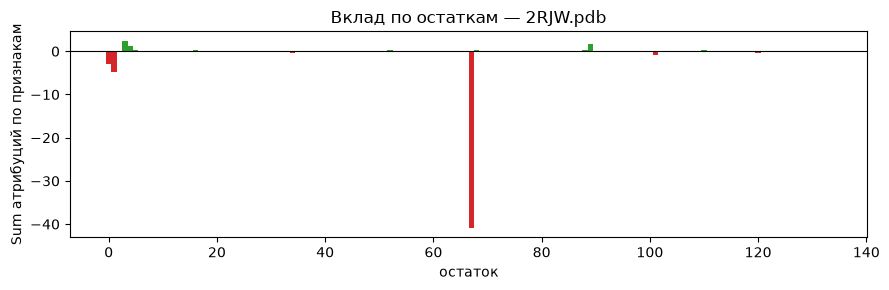

In [10]:
# Тот же тензор атрибуций, просуммированный по признакам вместо остатков —
# показывает, В КАКОМ МЕСТЕ структуры сосредоточена проблема.
per_residue_attr = res["attributions"].sum(dim=-1).numpy()  # [L], логит-юниты

worst_residues = sorted(per_residue_attr.argsort()[:8])
print("Остатки с наибольшим отрицательным вкладом (индексация с 0):")
for i in worst_residues:
    print(f"  остаток {i:3d}: {per_residue_attr[i]:+.3f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(len(per_residue_attr)), per_residue_attr, width=1.0,
       color=["#d62728" if v < 0 else "#2ca02c" for v in per_residue_attr])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("остаток")
ax.set_ylabel("Sum атрибуций по признакам")
ax.set_title(f"Вклад по остаткам — {res['path'].split('/')[-1]}")
plt.tight_layout()
plt.show()

### Диагностика любого белка одной командой

Всё выше — это разбор одного вызова `integrated_gradients()`. Оборачиваем его в `explain_protein()`: подать путь к любому PDB → получить логиты, топ-признаки, топ-остатки и два графика. Сравниваем три структуры из таблицы раздела 4 — от катастрофического разрыва цепи до погранично-приемлемой:

=== 2RJW.pdb  (L=134) ===
P(fold) = 0.000  |  fold_logit = -26.069  (эталон: 1.000 / +17.112)
Sum атрибуций = -42.184  (~= разность логитов -43.181)

Топ-8 признаков, понижающих P(fold):
  ω cos                         -7.055
  PCA-фрагмент 14               -6.725
  PCA-фрагмент 15               -5.282
  PCA-фрагмент 9                -4.831
  PCA-фрагмент 11               -2.989
  экспонированность (burial)    -2.551
  PCA-фрагмент 1                -1.981
  ψ sin                         -1.919

Остатки с наибольшим негативным вкладом: [np.int64(0), np.int64(1), np.int64(22), np.int64(34), np.int64(67), np.int64(71), np.int64(101), np.int64(120)]


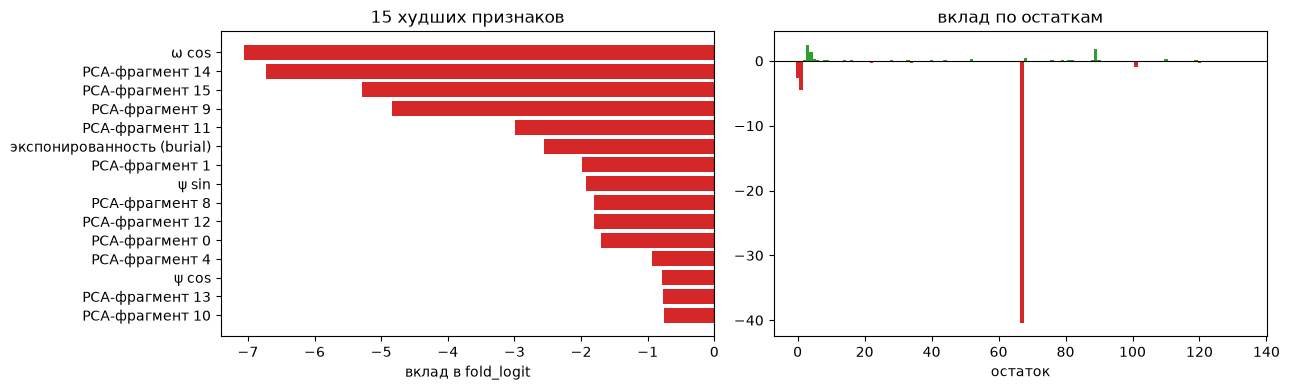

=== my_protein_2.pdb  (L=242) ===
P(fold) = 1.000  |  fold_logit = +16.610  (эталон: 1.000 / +16.796)
Sum атрибуций = +0.153  (~= разность логитов -0.186)

Топ-8 признаков, понижающих P(fold):
  стерич. конфликты             -1.504
  PCA-фрагмент 0                -0.869
  PCA-фрагмент 1                -0.491
  PCA-фрагмент 8                -0.424
  PCA-фрагмент 11               -0.260
  ψ sin                         -0.108
  ω sin                         -0.103
  Cα-Cα дист.                   -0.092

Остатки с наибольшим негативным вкладом: [np.int64(46), np.int64(77), np.int64(78), np.int64(80), np.int64(165), np.int64(193), np.int64(195), np.int64(240)]


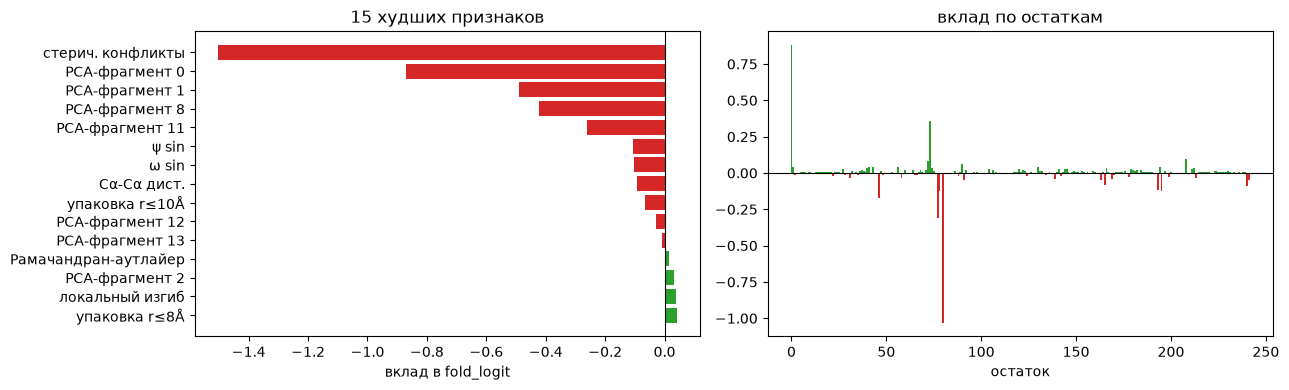

=== 2RJV.pdb  (L=67) ===
P(fold) = 1.000  |  fold_logit = +16.780  (эталон: 1.000 / +17.111)
Sum атрибуций = -0.303  (~= разность логитов -0.331)

Топ-8 признаков, понижающих P(fold):
  PCA-фрагмент 0                -0.573
  PCA-фрагмент 2                -0.413
  Cα-Cα дист.                   -0.157
  стерич. конфликты             -0.150
  H-связи                       -0.133
  PCA-фрагмент 9                -0.129
  PCA-фрагмент 12               -0.084
  ψ cos                         -0.061

Остатки с наибольшим негативным вкладом: [np.int64(2), np.int64(3), np.int64(8), np.int64(16), np.int64(20), np.int64(34), np.int64(52), np.int64(60)]


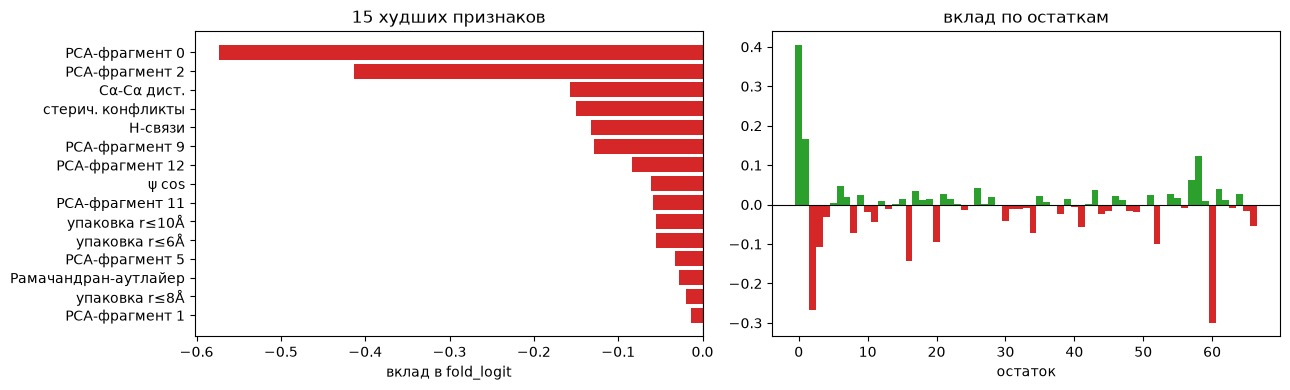

In [11]:
def explain_protein(pdb_path: str, top_k: int = 8, steps: int = 32) -> dict:
    """Полная диагностика одного белка: логиты, топ-признаки и топ-остатки,
    роняющие P(fold) относительно эталона `baseline_feats`. Печатает отчёт
    и рисует два графика (по признакам, по остаткам)."""
    r = integrated_gradients(pdb_path, baseline_feats, steps=steps)
    pf = r["attributions"].sum(dim=0).numpy()
    pr = r["attributions"].sum(dim=-1).numpy()
    name = pdb_path.split("/")[-1]

    print(f"=== {name}  (L={r['length']}) ===")
    print(f"P(fold) = {r['pfold_input']:.3f}  |  fold_logit = {r['logit_input']:+.3f}  "
          f"(эталон: {r['pfold_baseline']:.3f} / {r['logit_baseline']:+.3f})")
    print(f"Sum атрибуций = {r['attributions'].sum().item():+.3f}  "
          f"(~= разность логитов {r['logit_input'] - r['logit_baseline']:+.3f})")

    order = pf.argsort()
    print(f"\nТоп-{top_k} признаков, понижающих P(fold):")
    for i in order[:top_k]:
        print(f"  {FEATURE_NAMES[i]:28s} {pf[i]:+7.3f}")

    worst_res = sorted(pr.argsort()[:top_k])
    print(f"\nОстатки с наибольшим негативным вкладом: {worst_res}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    order_plot = order[:15]
    axes[0].barh([FEATURE_NAMES[i] for i in order_plot], pf[order_plot],
                 color=["#d62728" if v < 0 else "#2ca02c" for v in pf[order_plot]])
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].invert_yaxis()
    axes[0].set_title("15 худших признаков")
    axes[0].set_xlabel("вклад в fold_logit")

    axes[1].bar(range(len(pr)), pr, width=1.0,
                color=["#d62728" if v < 0 else "#2ca02c" for v in pr])
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("вклад по остаткам")
    axes[1].set_xlabel("остаток")
    plt.tight_layout()
    plt.show()
    return r


# Три случая из таблицы раздела 4: катастрофический разрыв цепи,
# провал похуже и погранично-приемлемая структура.
for p in ["data/2RJW.pdb", "data/my_protein_2.pdb", "data/2RJV.pdb"]:
    explain_protein(p)
    print()